# Custering K-Means

Hasta ahora, hemos hecho lo que se le llama aprendisaje supervisado, es decir, le dijimos a la computadora cual era el objetivo y cual eran los predictores. Ahora pasaremos a la parte de *unsupervised learning*, que aprende patrones y frecuencias respecto a distintos objetivos, o mas bien, sin objetivos.

## Cluster labels (grupo de etiquetas) como Funciones
Las columnas, tambien llamadas labels, features o atributos, pueden agruparse en disintas funciones , es decir podemos hacer un suconjunto de subconjuntos.
![clustering](images/clustering-km.png)
Esta tecnica se le llama K-means, que consiste en agrupar datos segun su cercania los unos a los otros. Esta tecnica es bastante util, pero aprender a utilizarla puede ser un poco dificil.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

df = pd.read_csv("data/housing.csv")
X = df.loc[:, ["MedInc", "Latitude", "Longitude"]]
X.head()

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25


In [5]:
# Crea una funcion de cluster
kmeans = KMeans(n_clusters = 6)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X['Cluster'].astype("category")

X.head()

,MedInc,Latitude,Longitude,Cluster
0,8.3252,37.88,-122.23,5
1,8.3014,37.86,-122.22,5
2,7.2574,37.85,-122.24,5
3,5.6431,37.85,-122.25,5
4,3.8462,37.85,-122.25,0


Como vemos, ahora tenemos una nueva categoria que nos dice a que grupo pertenece cada uno de nuestros registros.

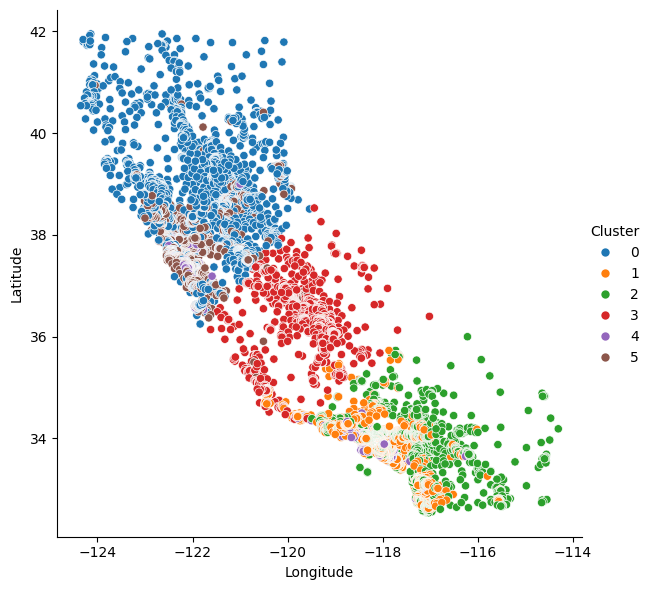

In [8]:
# graficamos para ver mejor la clusterizacion
sns.relplot(
    x = "Longitude", y = "Latitude", hue = "Cluster", data = X, height = 6)

Puede que se aun poco confuso ver por que aunque hay alugnos puntos mas cerca que otros entonces no son del mismo color, pero podriamos decir que esta grafica esta en 3 dimenciones.

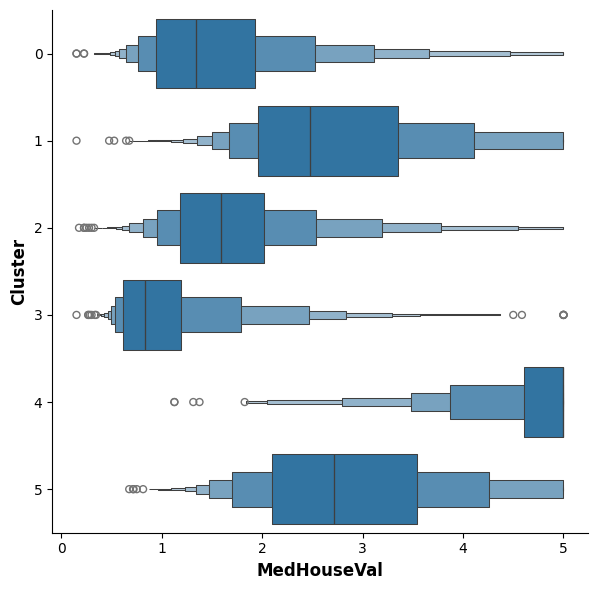

In [13]:
X["MedHouseVal"] = df['MedHouseVal']
sns.catplot(x = "MedHouseVal", y = "Cluster", data = X, kind = "boxen", height = 6)